## Notebook changes or specifying
in this notebook i watn to achieve different things:
* understand why i dont get color in my motorcycles (why are they mostly gray)
* attempt to over fit and underfit to see each scenario
* attempt to improve the training set, by: seeing how image size has an effect, centering images based on the wheels, or to improve how centered they might be.
* try different loss algorithms
* understanding in depth what im doing to make adjustments and improve image generation.


In [1]:
import tensorflow as tf
from tensorflow import keras
import math
#from keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, Flatten, Dense, Lambda, Reshape

from keras import ops
from keras import layers

from keras import Model, Input
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import os 
import sys

sys.path.append(os.path.abspath('..'))
from proyecto1_deep_learning.data_loader import load_data_3



2026-02-25 13:57:29.525852: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-25 13:57:29.602352: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-25 13:57:31.627380: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 7344164359284095115
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 3758096384
locality {
  bus_id: 1
  links {
  }
}
incarnation: 4781631226203934130
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6"
xla_global_id: 416903419
]
2.20.0
Num GPUs Available:  1


I0000 00:00:1772049455.063895    3564 gpu_device.cc:2020] Created device /device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
##why the helly does this not work?
x_train, x_test = load_data_3()

image_shape = x_train.shape[1:]
num_channels = image_shape[2]
print(f"Image shape: {image_shape}")

Image shape: (128, 128, 3)


In [4]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

In [5]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print(f'x_train min: {x_train.min()}, max: {x_train.max()}')
print(f'x_test min: {x_test.min()}, max: {x_test.max()}')

x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


In [6]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

In [7]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon


In [8]:
latent_dim = 2
image_size_x = 128
image_size_y = 128

encoder_inputs = keras.Input(shape=(image_size_x, image_size_y, 3))

x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

shape_before_flattening = x.shape[1:]

x = layers.Flatten()(x)
x = layers.Dense(16)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(np.prod(shape_before_flattening))(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Reshape(shape_before_flattening)(x)

x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

decoder_outputs = layers.Conv2DTranspose(
    3, 3, activation="sigmoid", padding="same"
)(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

I0000 00:00:1772049455.578129    3564 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ activation_1[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │    262,160 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 16)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ activation_4[0][

 Total params: 652,628 (2.49 MB)

 Trainable params: 651,636 (2.49 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16384)          │        49,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,094,851 (4.18 MB)

 Trainable params: 1,061,123 (4.05 MB)

 Non-trainable params: 33,728 (131.75 KB)

In [9]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # MSE loss (no automatic reduction)
            reconstruction_loss = ops.mean(
                ops.sum(
                    ops.square(data - reconstruction),
                    axis=(1, 2, 3),
                )
            )

            # KL divergence
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [10]:
motorcycle_brum_brum = np.concatenate([x_train, x_test], axis=0)


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(motorcycle_brum_brum, epochs=100)




Epoch 1/100


2026-02-25 13:57:44.153120: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f249c001690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-25 13:57:44.153209: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-02-25 13:57:44.362537: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-25 13:57:45.438468: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-25 13:57:57.526499: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng1{k2=3,k3=0} for conv (f32[32,64,65,65]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,32,32]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput"

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - kl_loss: 0.0727 - loss: 9475.8840 - reconstruction_loss: 9475.8112

2026-02-25 13:58:03.036305: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1178', 4 bytes spill stores, 4 bytes spill loads

2026-02-25 13:58:03.810892: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1178', 4 bytes spill stores, 4 bytes spill loads

2026-02-25 13:58:04.198189: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2344', 4 bytes spill stores, 4 bytes spill loads

2026-02-25 13:58:04.229949: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2344', 4 bytes spill stores, 4 bytes spill loads

2026-02-25 13:58:12.573337: E external/local_xla

7/7 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - kl_loss: 0.3841 - loss: 9308.1719 - reconstruction_loss: 9307.7871
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - kl_loss: 11554.7617 - loss: 17514.9434 - reconstruction_loss: 5960.1816 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ -7s -1257734us/step - kl_loss: 0.3232 - loss: 3777.1985 - reconstruction_loss: 3776.8752
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - kl_loss: 0.0151 - loss: 3297.0833 - reconstruction_loss: 3297.0686
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - kl_loss: 8.3364e-04 - loss: 2515.6211 - reconstruction_loss: 2515.6204
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - kl_loss: 3.0545e-04 - loss: 2323.8577 - reconstruction_loss: 2323.8574
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - kl_loss: 3.7164e-04 - loss: 2210.3584 - reconstruction_loss: 2210.3584
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - kl_loss: 4.2624e-04 - loss: 2175.4495 - reconstruction_loss: 2175.4490
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


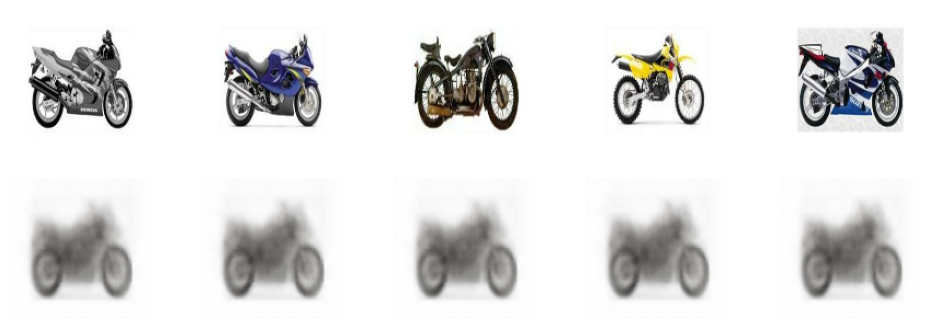

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def show_reconstructions(model, data, n=5):
    z_mean, z_log_var, z = model.encoder.predict(data[:n])
    reconstructions = model.decoder.predict(z)

    plt.figure(figsize=(12, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i])
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructions[i])
        plt.axis("off")

    plt.show()

show_reconstructions(vae, motorcycle_brum_brum)

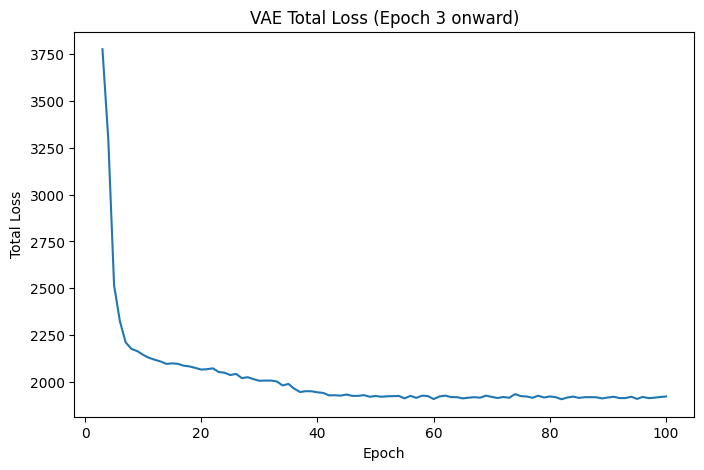

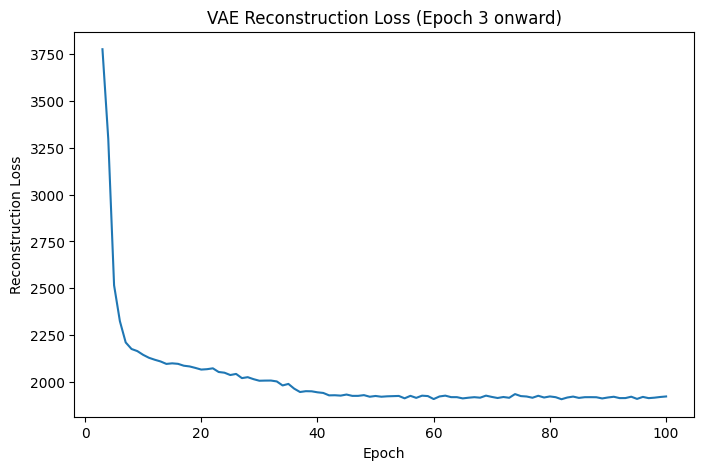

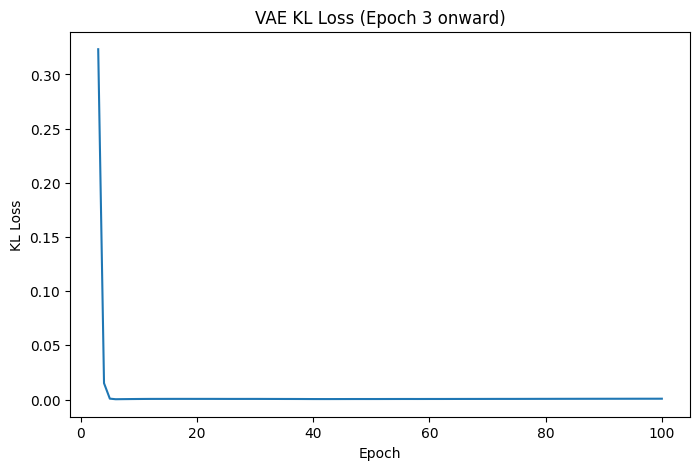

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Ignore first 2 epochs
epochs = np.arange(3, len(history.history["loss"]) + 1)

total_loss = history.history["loss"][2:]
recon_loss = history.history["reconstruction_loss"][2:]
kl_loss = history.history["kl_loss"][2:]

# ---- Total Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, total_loss)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("VAE Total Loss (Epoch 3 onward)")
plt.show()

# ---- Reconstruction Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, recon_loss)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("VAE Reconstruction Loss (Epoch 3 onward)")
plt.show()

# ---- KL Loss ----
plt.figure(figsize=(8, 5))
plt.plot(epochs, kl_loss)
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("VAE KL Loss (Epoch 3 onward)")
plt.show()

In [13]:
LATENT_DIM = 2

def generate_images(
    decoder: keras.Model,
    n_images: int,
) -> np.ndarray:
    """Sample n_images points from N(0, I) and decode them into images.

    Args:
        decoder:   The standalone decoder model.
        n_images:  How many images to generate.

    Returns:
        numpy array of shape (n_images, H, W, C) with pixel values in [0, 1].
    """
    z = np.random.normal(size=(n_images, LATENT_DIM)).astype("float32")
    generated = decoder.predict(z, verbose=0)
    return generated


def plot_generated_images(
    generated: np.ndarray,
    n_images: int,
    save_path: str = None,
) -> None:
    """Plot and save generated images.

    Args:
        generated:  numpy array of generated images.
        n_images:   How many images to plot.
        save_path:  Where to save the figure (auto-named if None).
    """
    cols = min(n_images, 5)
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(f"Generated Images (n={n_images})", fontsize=12)

    axes_flat = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes_flat):
        if i < n_images:
            ax.imshow(np.clip(generated[i], 0, 1))
        ax.axis("off")

    plt.tight_layout()

    if save_path is None:
        save_path = f"./reports/figures/3.04-smdeo-generated_images_{n_images}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Generated images saved to {save_path}")


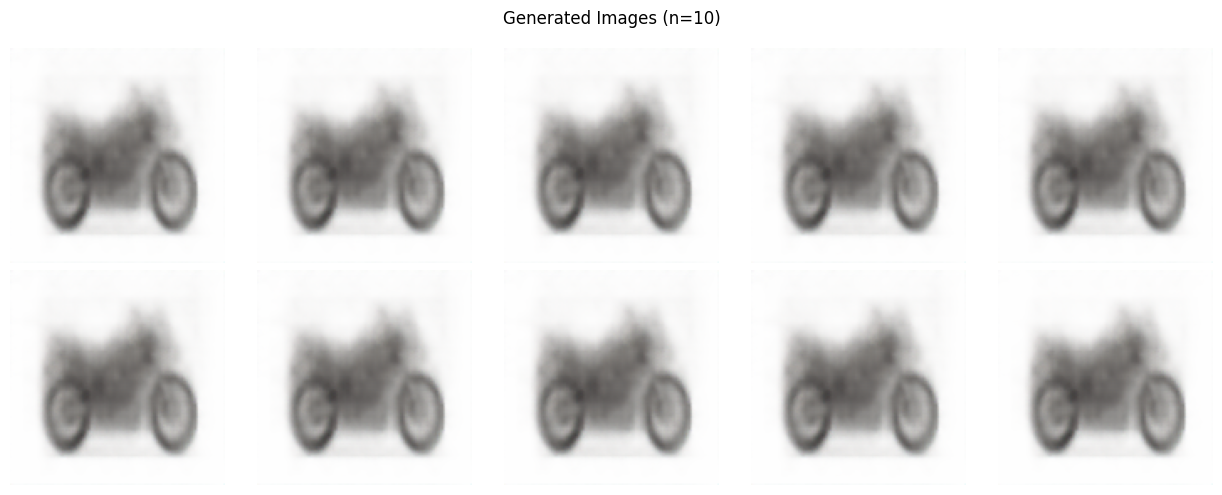

Generated images saved to ./reports/figures/3.04-smdeo-generated_images_10.png


In [14]:
generated_images = generate_images(decoder, n_images=10)
plot_generated_images(generated_images, n_images=10)

In [15]:
models_path = "./models"

# ---- Save encoder ----
encoder.save(os.path.join(models_path, "encoder_smdo_3-04.keras"))

# ---- Save decoder ----
decoder.save(os.path.join(models_path, "decoder_smdo_3-04.keras"))

# ---- Save full VAE ----
# vae.save("./models/vae_smdo_3-04.keras", include_optimizer=True)
# vae.save("./models/vae_smdo_3-04.keras")
# vae.save("./models/vae_savedmodel_smdo_3-04", save_format="tf")
# vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

print("Models saved successfully")


# try:
#     models_path = "../models"

#     # ---- Save encoder ----
#     encoder.save(os.path.join(models_path, "encoder_smdo_3-04.keras"))

#     # ---- Save decoder ----
#     decoder.save(os.path.join(models_path, "decoder_smdo_3-04.keras"))

#     # ---- Save full VAE ----
#     vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

#     print("Models saved successfully")
# except Exception as e:
#     models_path = "./models"

#     # ---- Save encoder ----
#     encoder.save(os.path.join(models_path, "encoder_smdo_3-04.keras"))

#     # ---- Save decoder ----
#     decoder.save(os.path.join(models_path, "decoder_smdo_3-04.keras"))

#     # ---- Save full VAE ----
#     vae.save(os.path.join(models_path, "vae_smdo_3-04.keras"))

#     print("Models saved successfully")

Models saved successfully


### checking this saved:

In [16]:
import os

models = [
    "./models/decoder_smdo_3-04.keras",
    "./models/encoder_smdo_3-04.keras",
    "./models/vae_smdo_3-04.keras",
]

for path in models:
    print(f"{path} exists:", os.path.exists(path))

./models/decoder_smdo_3-04.keras exists: True
./models/encoder_smdo_3-04.keras exists: True
./models/vae_smdo_3-04.keras exists: True


In [17]:
from keras.models import load_model

custom_objects = {
    "VAE": VAE,
    "Sampling": Sampling,
}

decoder_loaded = load_model(
    "./models/decoder_smdo_3-05.keras",
    custom_objects=custom_objects
)

encoder_loaded = load_model(
    "./models/encoder_smdo_3-05.keras",
    custom_objects=custom_objects
)

# vae_loaded = load_model(
#     "./models/vae_smdo_3-04.keras",
#     custom_objects=custom_objects
# )

print("All models loaded successfully")

ValueError: File not found: filepath=./models/decoder_smdo_3-05.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
import numpy as np

dummy = np.random.rand(1, 128, 128, 3).astype("float32")

z_mean, z_log_var, z = encoder_loaded.predict(dummy)
print("Encoder output shape:", z.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Encoder output shape: (1, 2)


In [ ]:
latent = np.random.normal(size=(1, 2)).astype("float32")
recon = decoder_loaded.predict(latent)
print("Decoder output shape:", recon.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Decoder output shape: (1, 128, 128, 3)


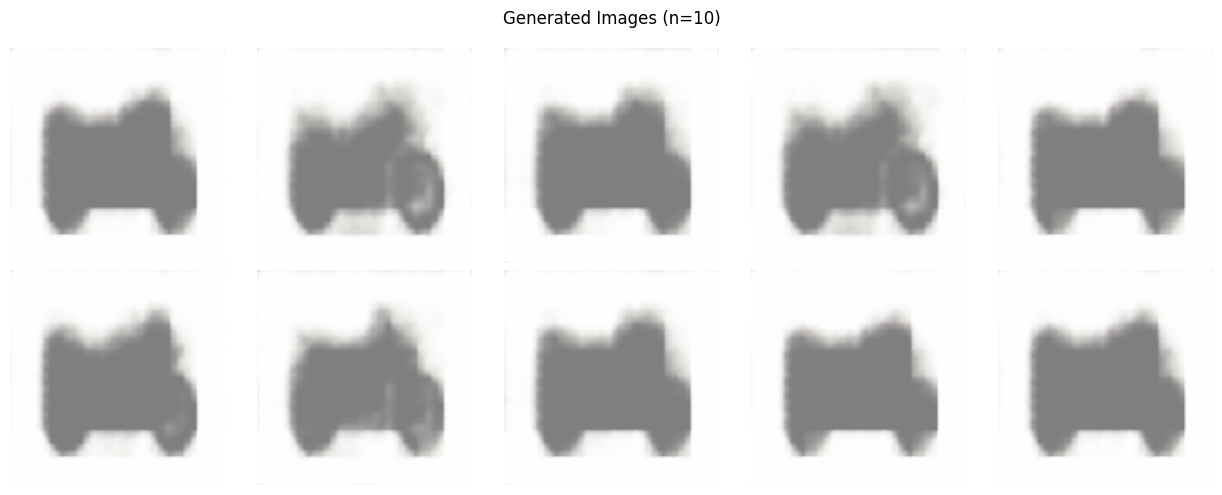

Generated images saved to ./reports/figures/3.04-smdeo-generated_images_10.png


In [ ]:
generated_images = generate_images(decoder_loaded, n_images=10)
plot_generated_images(generated_images, n_images=10)